In [110]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split

In [111]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

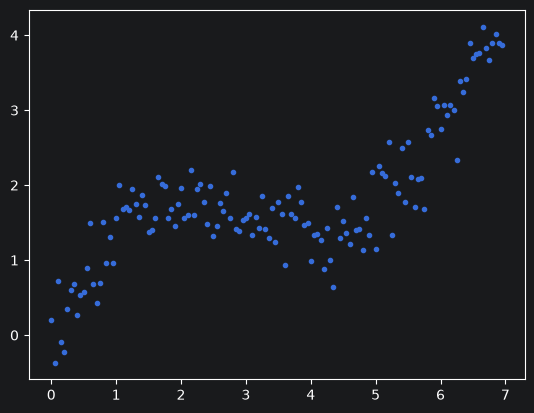

(140,)


In [112]:
X = np.arange(0, 7, 0.05)
Y = np.sin(X) + 0.3 * np.random.randn(X.shape[0]) + 0.5 * X
plt.plot(X, Y, '.')
plt.show()
print(X.shape)

In [113]:
X = X.reshape((-1, 1))
Y = Y.reshape((-1, 1))

# Separação, desenvolvimento (30) e teste (70)
X_dev, X_test, Y_dev, Y_test = train_test_split(
    X, Y, test_size=0.8, random_state=42
)
# Separação treino (80) e validação (20)
X_train, X_val, Y_train, Y_val = train_test_split(
    X_dev, Y_dev, test_size=0.2, random_state=42
)

# (row, column)
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(22, 1)
(6, 1)
(112, 1)


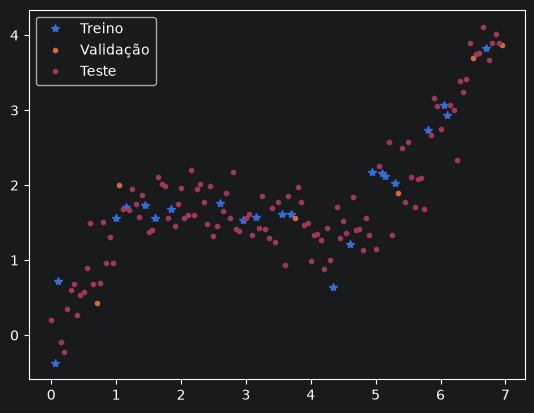

In [114]:
plt.plot(X_train, Y_train, '*', label='Treino')
plt.plot(X_val, Y_val, '.', label='Validação')
plt.plot(X_test, Y_test, '.', label='Teste')
plt.legend()
plt.show()

In [115]:
# Transformação dos dados em tensores Pytorch
x_train = torch.FloatTensor(X_train).to(device)
y_train = torch.FloatTensor(Y_train).to(device)
x_val = torch.FloatTensor(X_val).to(device)
y_val = torch.FloatTensor(Y_val).to(device)
x_test = torch.FloatTensor(X_test).to(device)
y_test = torch.FloatTensor(Y_test).to(device)

Modelo com uma única camada (linear)

In [116]:
class MLPLin(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(MLPLin, self).__init__()
        self.rede = nn.Sequential(
            nn.Linear(input_dim, output_dim),
        )

    def forward(self, x):
        return self.rede(x)

In [117]:
input_dim = 1  # número de atributos do Iris
output_dim = 1  # número de classes
modeloLin = MLPLin(input_dim, output_dim).to(device)

In [118]:
print(modeloLin)
from torchsummary import summary

summary(modeloLin, (100, 1), device=device)

MLPLin(
  (rede): Sequential(
    (0): Linear(in_features=1, out_features=1, bias=True)
  )
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1               [-1, 100, 1]               2
Total params: 2
Trainable params: 2
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [119]:
# Otimizador e Função de Custo
eta = 0.02
loss_function = nn.MSELoss()
optimizer = torch.optim.SGD(modeloLin.parameters(), lr=eta)

In [120]:
def train_network(
        model,
        optimizer,
        loss_function,
        x_train,
        y_train,
        x_val,
        y_val,
        num_epochs,
        train_losses,
        val_losses,
):
    for epoch in range(num_epochs):
        # zerando os gradientes da época anterior
        optimizer.zero_grad()
        # fase de propagação
        output_train = model(x_train)
        # cálculo do erro (função de custo - loss function)
        loss_train = loss_function(output_train, y_train)
        # fase de retroprogação
        loss_train.backward()
        # atualização dos pesos da rede
        optimizer.step()

        output_val = model(x_val)
        loss_val = loss_function(output_val, y_val)

        train_losses[epoch] = loss_train.item()
        val_losses[epoch] = loss_val.item()

        if (epoch + 1) % 1000 == 0:
            print(
                f"Epoch {epoch + 1}/{num_epochs}, Erro Treino: {loss_train.item():.4f}, Erro Validação: {loss_val.item():.4f}"
            )

In [121]:
num_epochs = 20000
train_losses = np.zeros(num_epochs)
val_losses = np.zeros(num_epochs)

In [122]:
train_network(
    modeloLin,
    optimizer,
    loss_function,
    x_train,
    y_train,
    x_val,
    y_val,
    num_epochs,
    train_losses,
    val_losses,
)

Epoch 1000/20000, Erro Treino: 0.3277, Erro Validação: 0.5642
Epoch 2000/20000, Erro Treino: 0.3277, Erro Validação: 0.5642
Epoch 3000/20000, Erro Treino: 0.3277, Erro Validação: 0.5642
Epoch 4000/20000, Erro Treino: 0.3277, Erro Validação: 0.5642
Epoch 5000/20000, Erro Treino: 0.3277, Erro Validação: 0.5642
Epoch 6000/20000, Erro Treino: 0.3277, Erro Validação: 0.5642
Epoch 7000/20000, Erro Treino: 0.3277, Erro Validação: 0.5642
Epoch 8000/20000, Erro Treino: 0.3277, Erro Validação: 0.5642
Epoch 9000/20000, Erro Treino: 0.3277, Erro Validação: 0.5642
Epoch 10000/20000, Erro Treino: 0.3277, Erro Validação: 0.5642
Epoch 11000/20000, Erro Treino: 0.3277, Erro Validação: 0.5642
Epoch 12000/20000, Erro Treino: 0.3277, Erro Validação: 0.5642
Epoch 13000/20000, Erro Treino: 0.3277, Erro Validação: 0.5642
Epoch 14000/20000, Erro Treino: 0.3277, Erro Validação: 0.5642
Epoch 15000/20000, Erro Treino: 0.3277, Erro Validação: 0.5642
Epoch 16000/20000, Erro Treino: 0.3277, Erro Validação: 0.5642
E

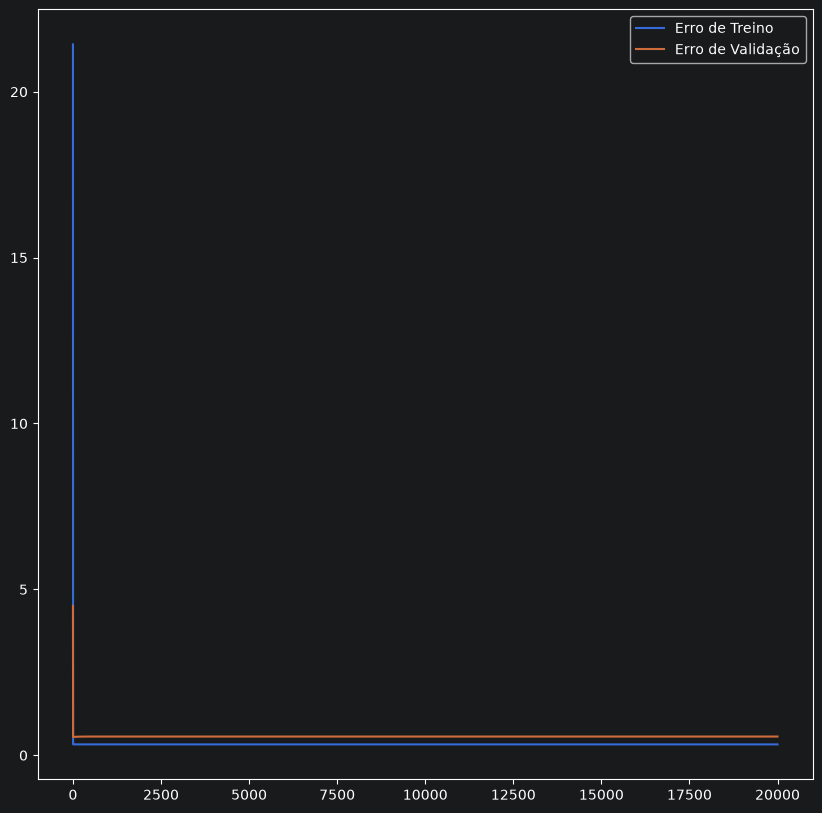

In [123]:
plt.figure(figsize=(10, 10))
plt.plot(train_losses, label='Erro de Treino')
plt.plot(val_losses, label='Erro de Validação')
plt.legend()
plt.show()

In [124]:
predictions_train = []
predictions_val = []
predictions_test = []
with torch.no_grad():
    predictions_train = modeloLin(x_train)
    predictions_val = modeloLin(x_val)
    predictions_test = modeloLin(x_test)

In [125]:
erro_train = loss_function(predictions_train, y_train)
erro_val = loss_function(predictions_val, y_val)
erro_test = loss_function(predictions_test, y_test)
# from sklearn.metrics import accuracy_score
# acc_train = accuracy_score(x_train, predictions_train)
print(f"Erro de Treino: {erro_train}")
print(f"Erro de Validação: {erro_val}")
print(f"Erro de Teste: {erro_test}")

Erro de Treino: 0.327723890542984
Erro de Validação: 0.5641624927520752
Erro de Teste: 0.35752570629119873


In [128]:
def to_numpy(tensor):
    return tensor.detach().cpu().numpy()

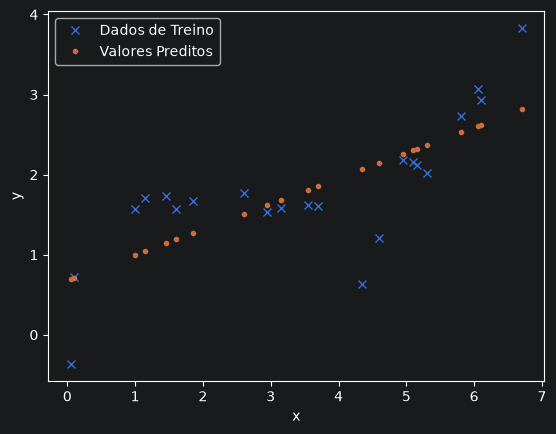

In [127]:
plt.plot(to_numpy(x_train), to_numpy(y_train), 'x', label='Dados de Treino')
plt.plot(to_numpy(x_train), to_numpy(predictions_train), '.', label='Valores Preditos')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

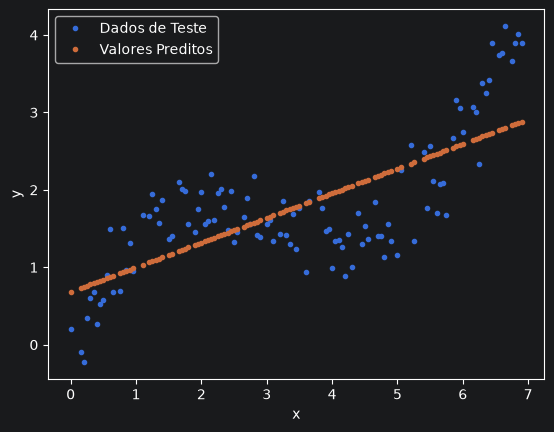

In [129]:
plt.plot(to_numpy(x_test), to_numpy(y_test), '.', label='Dados de Teste')
plt.plot(to_numpy(x_test), to_numpy(predictions_test), '.', label='Valores Preditos')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

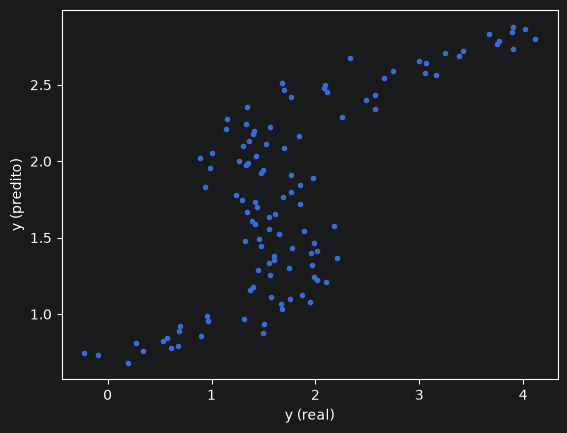

In [130]:
plt.plot(to_numpy(y_test), to_numpy(predictions_test), '.')
plt.xlabel('y (real)')
plt.ylabel('y (predito)')
# plt.legend()
plt.show()

Modelo com várias camadas

In [133]:
class MLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(MLP, self).__init__()
        self.rede = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim),
        )

    def forward(self, x):
        return self.rede(x)

In [134]:
input_dim = 1
output_dim = 1
modelo = MLP(input_dim, output_dim).to(device)

In [135]:
from torchsummary import summary

print(modelo)
summary(modelo, (100, 1), device=device)

MLP(
  (rede): Sequential(
    (0): Linear(in_features=1, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1             [-1, 100, 512]           1,024
              ReLU-2             [-1, 100, 512]               0
            Linear-3             [-1, 100, 256]         131,328
              ReLU-4             [-1, 100, 256]               0
            Linear-5             [-1, 100, 128]          32,896
              ReLU-6             [-1, 100, 128]               0
            Linear-7              [-1, 100, 64]           8,256
              ReLU-8  

In [136]:
# Otimizador e Função de Custo
eta = 0.02
loss_function = nn.MSELoss()
# loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(modelo.parameters(), lr=eta)

In [137]:
x_train = torch.FloatTensor(X_train).to(device)
y_train = torch.FloatTensor(Y_train).to(device)
x_val = torch.FloatTensor(X_val).to(device)
y_val = torch.FloatTensor(Y_val).to(device)
x_test = torch.FloatTensor(X_test).to(device)
y_test = torch.FloatTensor(Y_test).to(device)

In [138]:
def train_network(
        model,
        optimizer,
        loss_function,
        x_train,
        y_train,
        x_val,
        y_val,
        num_epochs,
        train_losses,
        val_losses,
):
    for epoch in range(num_epochs):
        # zerando os gradientes da época anterior
        optimizer.zero_grad()
        # fase de propagação
        output_train = model(x_train)
        # cálculo do erro (função de custo - loss function)
        loss_train = loss_function(output_train, y_train)
        # fase de retroprogação
        loss_train.backward()
        # atualização dos pesos da rede
        optimizer.step()

        # avaliando o modelo com o conjunto de validação
        output_val = model(x_val)
        loss_val = loss_function(output_val, y_val)

        train_losses[epoch] = loss_train.item()
        val_losses[epoch] = loss_val.item()

        if (epoch + 1) % 1000 == 0:
            print(
                f"Epoch {epoch + 1}/{num_epochs}, Erro Treino: {loss_train.item():.4f}, Erro Validação: {loss_val.item():.4f}"
            )

In [139]:
num_epochs = 20000
train_losses = np.zeros(num_epochs)
val_losses = np.zeros(num_epochs)

In [140]:
train_network(
    modelo,
    optimizer,
    loss_function,
    x_train,
    y_train,
    x_val,
    y_val,
    num_epochs,
    train_losses,
    val_losses,
)

Epoch 1000/20000, Erro Treino: 0.2022, Erro Validação: 0.2689
Epoch 2000/20000, Erro Treino: 0.1245, Erro Validação: 0.3002
Epoch 3000/20000, Erro Treino: 0.1037, Erro Validação: 0.2800
Epoch 4000/20000, Erro Treino: 0.0496, Erro Validação: 0.2680
Epoch 5000/20000, Erro Treino: 0.0115, Erro Validação: 0.2429
Epoch 6000/20000, Erro Treino: 0.0092, Erro Validação: 0.2286
Epoch 7000/20000, Erro Treino: 0.0084, Erro Validação: 0.2290
Epoch 8000/20000, Erro Treino: 0.0078, Erro Validação: 0.2248
Epoch 9000/20000, Erro Treino: 0.0075, Erro Validação: 0.2163
Epoch 10000/20000, Erro Treino: 0.0337, Erro Validação: 0.2553
Epoch 11000/20000, Erro Treino: 0.0333, Erro Validação: 0.2477
Epoch 12000/20000, Erro Treino: 0.0039, Erro Validação: 0.2122
Epoch 13000/20000, Erro Treino: 0.0026, Erro Validação: 0.1944
Epoch 14000/20000, Erro Treino: 0.0020, Erro Validação: 0.2015
Epoch 15000/20000, Erro Treino: 0.0020, Erro Validação: 0.2004
Epoch 16000/20000, Erro Treino: 0.0016, Erro Validação: 0.1975
E

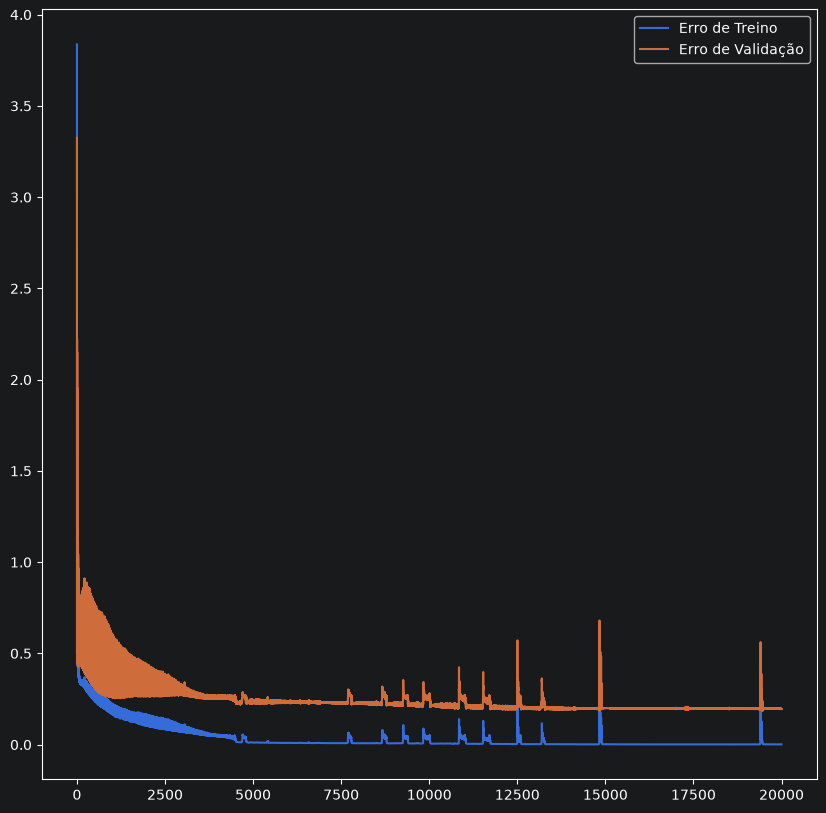

In [141]:
plt.figure(figsize=(10, 10))
plt.plot(train_losses, label='Erro de Treino')
plt.plot(val_losses, label='Erro de Validação')
plt.legend()
plt.show()

In [147]:
predictions_train = []
predictions_val = []
predictions_test = []
with torch.no_grad():
    predictions_train = modelo(x_train)
    predictions_val = modelo(x_val)
    predictions_test = modelo(x_test)

erro_train = loss_function(predictions_train, y_train)
erro_val = loss_function(predictions_val, y_val)
erro_test = loss_function(predictions_test, y_test)

print(f"Erro de Treino: {erro_train}")
print(f"Erro de Validação: {erro_val}")
print(f"Erro de Teste: {erro_test}")

Erro de Treino: 0.0015252325683832169
Erro de Validação: 0.19538909196853638
Erro de Teste: 0.17214252054691315


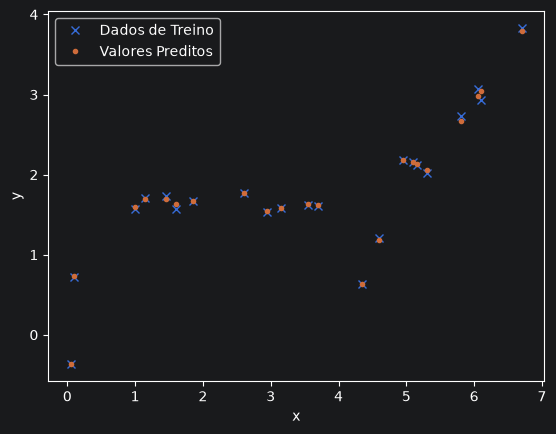

In [149]:
plt.plot(to_numpy(x_train), to_numpy(y_train), 'x', label='Dados de Treino')
plt.plot(to_numpy(x_train), to_numpy(predictions_train), '.', label='Valores Preditos')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

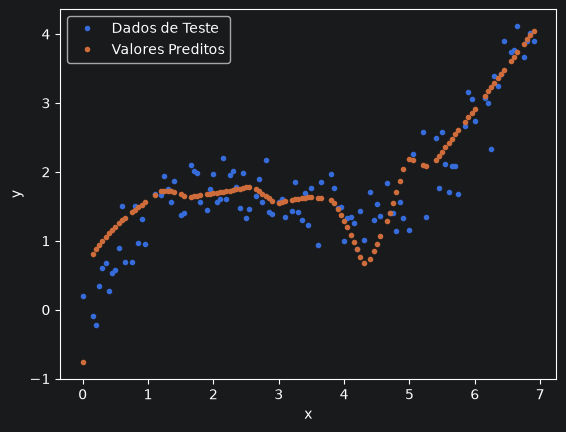

In [150]:
plt.plot(to_numpy(x_test), to_numpy(y_test), '.', label='Dados de Teste')
plt.plot(to_numpy(x_test), to_numpy(predictions_test), '.', label='Valores Preditos')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

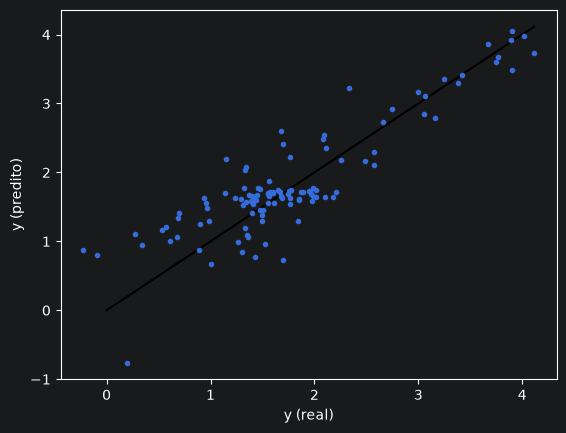

In [159]:
y_test_cpu = y_test.detach().cpu()
pred_cpu = predictions_test.detach().cpu()

plt.plot([0, torch.max(y_test_cpu)], [0, torch.max(y_test_cpu)], 'black')
plt.plot(y_test_cpu, pred_cpu, '.')
plt.xlabel('y (real)')
plt.ylabel('y (predito)')
plt.show()